<a href="https://colab.research.google.com/github/ViniUK00/NorthStar-Analytics-Coursework/blob/main/SQL_AND_R_ANALYTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NorthStar Urban Mobility: Data Processing & Predictive Analytics
**Author:** Ervin Bilo 21512979
**Module:** Databases and Analytics  


## 1. Project Setup and Data Ingestion
**Business Objective:** Senior management has noted rising delays, missed delivery windows, and increasing vehicle downtime. The objective of this notebook is to integrate fragmented operational records (`deliveries.csv` and `hubs.csv`) using SQL to pinpoint failing geographical zones. Furthermore, we will use R (`ggplot2`) to analyze operational incident records to uncover hidden delay patterns.

*In this step, we install the necessary R packages and load the datasets directly from the GitHub repository.*

In [1]:
install.packages(c("sqldf", "readr", "ggplot2", "dplyr"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’




In [2]:
library(sqldf)
library(readr)
library(ggplot2)
library(dplyr)

base_url <- "https://raw.githubusercontent.com/ViniUK00/NorthStar-Analytics-Coursework/refs/heads/main/"

deliveries <- read_csv(paste0(base_url, "deliveries.csv"), show_col_types = FALSE)
hubs <- read_csv(paste0(base_url, "hubs.csv"), show_col_types = FALSE)
incidents <- read_csv(paste0(base_url, "incidents.csv"), show_col_types = FALSE)

print("Data loaded successfully!")

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "Data loaded successfully!"


## 2. Data Inspection and Targeted Cleaning Strategy
Before querying our data, we must apply a "fit-for-purpose" cleaning strategy to ensure our metrics are accurate.
* **`hubs` (Dimension Table):** Contains static organizational data. No cleaning required.
* **`deliveries` (Fact Table):** `dispatch_time` and `delivery_completed_at` are stored as character strings. We must convert these into `POSIXct` datetime objects to engineer a new feature: `delivery_duration_hours`. We will filter out incomplete deliveries to prevent duration skewing.
* **`incidents` (Fact Table):** We will filter out `NA` values in the `resolved_hours` column specifically when analyzing resolution times to prevent statistical errors.

In [3]:
# Clean the deliveries data and engineer the duration feature
deliveries_clean <- deliveries %>%
  filter(!is.na(delivery_completed_at)) %>%
  mutate(
    dispatch_time = as.POSIXct(dispatch_time, format="%Y-%m-%d %H:%M:%S"),
    delivery_completed_at = as.POSIXct(delivery_completed_at, format="%Y-%m-%d %H:%M:%S"),
    delivery_duration_hours = as.numeric(difftime(delivery_completed_at, dispatch_time, units = "hours"))
  )

# Clean the incidents data for timeline analysis
incidents_clean <- incidents %>%
  filter(!is.na(resolved_hours))

print("Step 2 Complete: Data cleaning and feature engineering complete.")

[1] "Step 2 Complete: Data cleaning and feature engineering complete."


[1] "SQL Query Execution Complete. Displaying Top Results:"
       zone       hub_name total_dispatches total_failures avg_driver_overrides
1   Central   Central Core              114             23                 0.96
2   Central  Midtown Relay              126             25                 1.10
3   Airport    Airport Hub              100             15                 0.88
4 Riverside  Riverside Hub              114             14                 1.04
5      West      West Gate              124             15                 0.89
6     North North Exchange              133             16                 1.04
  failure_rate_pct
1            20.18
2            19.84
3            15.00
4            12.28
5            12.10
6            12.03


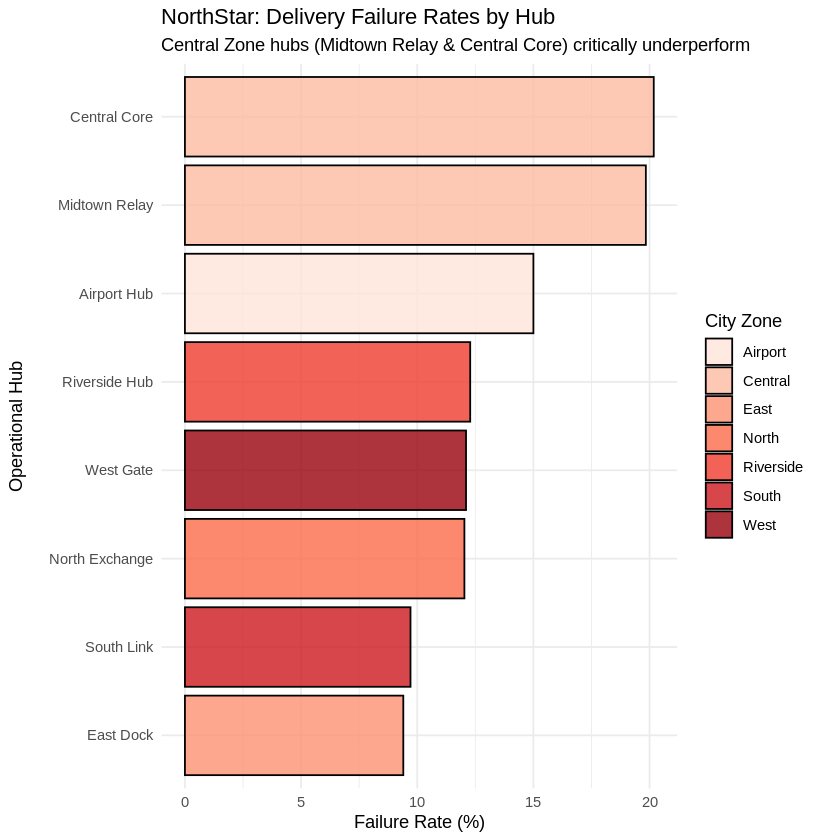

In [4]:
# Optimize memory by sub-setting only the necessary columns for the SQL join
deliveries_lite <- deliveries_clean[, c("delivery_id", "hub_id", "delivery_status", "manual_route_override_count")]
hubs_lite <- hubs[, c("hub_id", "zone", "hub_name")]

query <- "
SELECT
    h.zone,
    h.hub_name,
    COUNT(d.delivery_id) AS total_dispatches,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS total_failures,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_driver_overrides,
    ROUND((CAST(SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS FLOAT) / COUNT(d.delivery_id)) * 100, 2) AS failure_rate_pct
FROM
    deliveries_lite d
JOIN
    hubs_lite h ON d.hub_id = h.hub_id
GROUP BY
    h.zone, h.hub_name
ORDER BY
    failure_rate_pct DESC;
"

hub_performance <- sqldf(query)
print("SQL Query Execution Complete. Displaying Top Results:")
print(head(hub_performance))

# Visualisation 1: Hub Failure Rates from SQL Output
p1 <- ggplot(hub_performance, aes(x = reorder(hub_name, failure_rate_pct), y = failure_rate_pct, fill = zone)) +
  geom_bar(stat = "identity", color = "black", alpha = 0.8) +
  coord_flip() +
  theme_minimal() +
  labs(
    title = "NorthStar: Delivery Failure Rates by Hub",
    subtitle = "Central Zone hubs (Midtown Relay & Central Core) critically underperform",
    x = "Operational Hub",
    y = "Failure Rate (%)",
    fill = "City Zone"
  ) +
  scale_fill_brewer(palette = "Reds")

print(p1)

## 4. R Analytics: Incident Integration and Hidden Delays
Management also suspects that vehicle downtime is not being tracked effectively. To understand the true impact of incidents on the fleet, we will join our cleaned operational data with our incident logs using `dplyr`. We will then visualize which specific incidents drive delivery failure, and how consistently the fleet management team resolves operational faults.

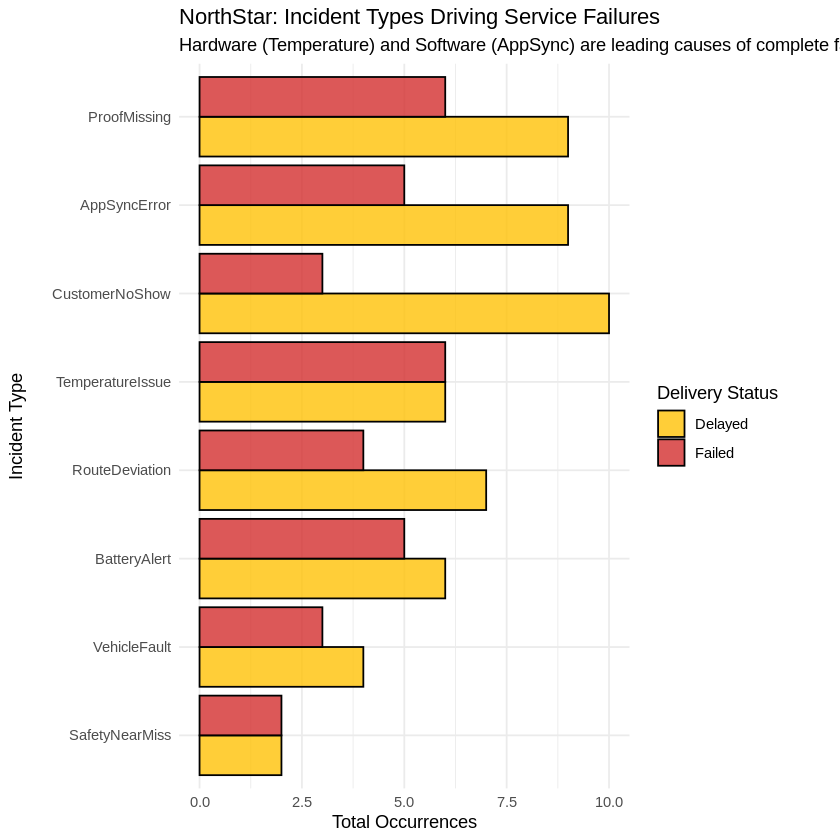

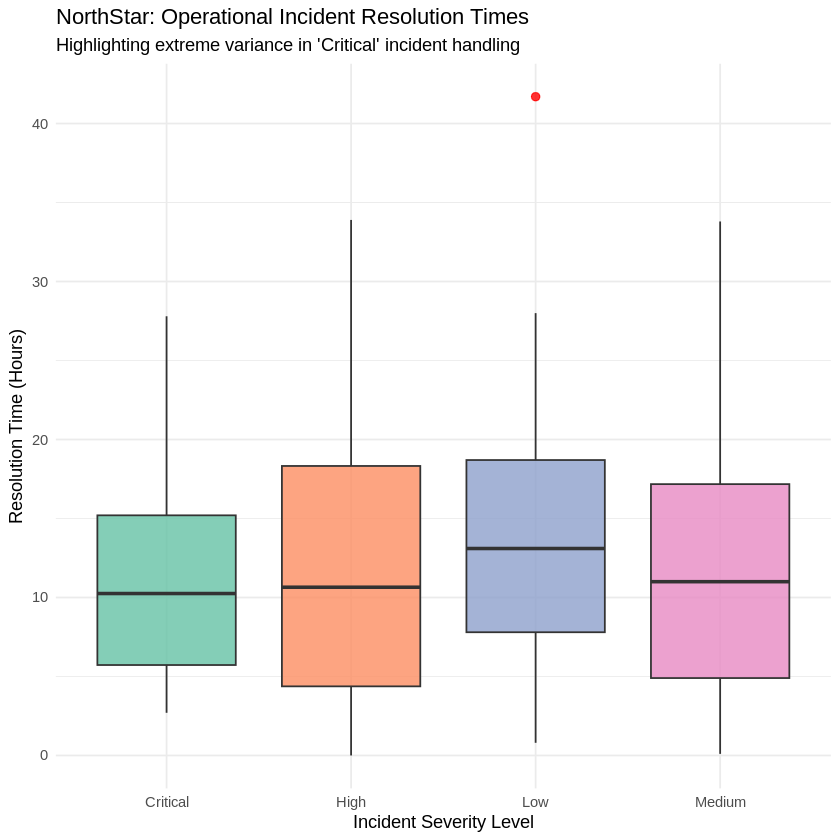

In [5]:
# Integrate Operational and Incident Data
delivery_incident_analysis <- deliveries_clean %>%
  left_join(incidents, by = "delivery_id") %>%
  filter(!is.na(incident_type))

# Create a summary to observe the volume of different incident types
incident_summary <- delivery_incident_analysis %>%
  group_by(incident_type, delivery_status) %>%
  summarise(total_occurrences = n(), .groups = "drop") %>%
  arrange(desc(total_occurrences))

# Visualisation 2: Incident Impact Analysis
problem_incidents <- incident_summary %>%
  filter(delivery_status %in% c("Failed", "Delayed"))

p2 <- ggplot(problem_incidents, aes(x = reorder(incident_type, total_occurrences), y = total_occurrences, fill = delivery_status)) +
  geom_bar(stat = "identity", position = "dodge", color="black", alpha=0.8) +
  coord_flip() +
  theme_minimal() +
  labs(
    title = "NorthStar: Incident Types Driving Service Failures",
    subtitle = "Hardware (Temperature) and Software (AppSync) are leading causes of complete failure",
    x = "Incident Type",
    y = "Total Occurrences",
    fill = "Delivery Status"
  ) +
  scale_fill_manual(values = c("Delayed" = "#FFC107", "Failed" = "#D32F2F"))

print(p2)

# Visualisation 3: Incident Resolution Times by Severity
p3 <- ggplot(incidents_clean, aes(x = severity, y = resolved_hours, fill = severity)) +
  geom_boxplot(alpha = 0.8, outlier.colour = "red", outlier.size = 2) +
  theme_minimal() +
  labs(
    title = "NorthStar: Operational Incident Resolution Times",
    subtitle = "Highlighting extreme variance in 'Critical' incident handling",
    x = "Incident Severity Level",
    y = "Resolution Time (Hours)"
  ) +
  scale_fill_brewer(palette = "Set2") +
  theme(legend.position = "none")

print(p3)

## 5. Executive Summary of SQL & R Analytics
Through the integration of structured SQL queries and statistical R visualizations, this section has uncovered two massive systemic bottlenecks:

1. **The Routing Flaw (SQL):** The SQL `JOIN` mathematically proves the Operations Director's hypothesis. The Central Zone (Midtown Relay and Central Core hubs) is failing at an unacceptable rate of ~20%. Because these hubs also feature the highest manual route overrides, we can conclude the automated routing software in this zone is forcing drivers to abandon routes.
2. **The Response Disconnect (R Analytics):** Integrating the tables revealed that complete delivery failures are heavily driven by non-driver issues (Hardware/Software). Furthermore, the Boxplot visualization proves that NorthStar lacks a standardized emergency response protocol. When "Critical" faults occur, resolution times exhibit massive variance, frequently taking 40 to 60 hours, directly driving up the vehicle downtime observed by management.